## Post Sentiment Classification Task

In [117]:
import pandas as pd
import numpy as np

train_data = pd.read_json("https://raw.githubusercontent.com/rpsoft/tad_course/main/reddit_sentiment_train.json")

validation_data = pd.read_json("https://raw.githubusercontent.com/rpsoft/tad_course/main/reddit_sentiment_validation.json")

test_data = pd.read_json("https://raw.githubusercontent.com/rpsoft/tad_course/main/reddit_sentiment_test.json")


# Examining Dataset Split between train,val and test
print('Trainning Data Percentage:',100*len(train_data)/(len(train_data)+len(validation_data)+len(test_data)),'\n')
print('Validation Data Percentage',100*len(validation_data)/(len(train_data)+len(validation_data)+len(test_data)),'\n')
print('Test Data Percentage',100*len(test_data)/(len(train_data)+len(validation_data)+len(test_data)))

Trainning Data Percentage: 63.01199190157296 

Validation Data Percentage 16.139749779369776 

Test Data Percentage 20.84825831905726


In [118]:
train_data[['body','sentiment.polarity']]

,body,sentiment.polarity
0,"It's a sad realization, isn't it?",negative
1,I told her a couple of minutes ago that I didn...,neutral
2,Leeches don't make good friends.,positive
3,I just ended it. Apparently she wasn't a good ...,positive
4,Good for you! Make sure you stick with it.,positive
...,...,...
12133,"If you were God, you'd know whether we would b...",neutral
12134,If I check my account balance in 5 minutes and...,neutral
12135,I don't know. Can you heal the sick with a tou...,negative
12136,... Give LeBron James a championship ring?,neutral


In [119]:
#Importing everything
import collections
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,precision_score,recall_score,accuracy_score,fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.svm import SVC
from matplotlib import pyplot as plt
from io import StringIO
import csv
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

Create the labels

In [120]:
#Function for label encoding
def create_label(x):
    if x == 'very negative':
        return 0  
    if x == 'negative':
        return 1 
    if x == 'neutral':
        return 2 
    if x == 'positive':
        return 3
    if x == 'very positive':
        return 4 
    
train_data['Class'] = train_data['sentiment.polarity'].apply(create_label)
validation_data['Class'] = validation_data['sentiment.polarity'].apply(create_label)
test_data['Class'] = test_data['sentiment.polarity'].apply(create_label)

#Storing the different labels:
train_labels = train_data['Class']
validation_labels = validation_data['Class']
test_labels = test_data['Class']

Analysing Class distribution

In [121]:
#function for analysing the stats
def stats(i,j):
  print(j)
  
  label_counts = collections.Counter(i)   #appear in descending order
  print(label_counts)

  for label in label_counts:
    print("class: " + str(label))         #according to the first seen class
    print(label_counts[label] / len(train_data))
  print('\n')

#Calling our stats function
stats(train_labels,'Trainning Data')
stats(validation_labels,'Validation Data')
stats(test_labels,'Test Data')

Trainning Data
Counter({2: 7679, 3: 3231, 1: 878, 4: 253, 0: 97})
class: 1
0.07233481627945296
class: 2
0.6326412918108419
class: 3
0.2661888284725655
class: 4
0.02084363157027517
class: 0
0.007991431866864393


Validation Data
Counter({2: 1961, 3: 845, 1: 215, 4: 73, 0: 15})
class: 4
0.006014170374031966
class: 2
0.16155874114351623
class: 3
0.06961608172680837
class: 1
0.01771296753995716
class: 0
0.001235788433020267


Test Data
Counter({2: 2514, 3: 1102, 1: 282, 4: 86, 0: 32})
class: 2
0.20711814137419673
class: 3
0.09078925687922228
class: 4
0.007085187015982864
class: 1
0.023232822540781017
class: 0
0.0026363486571099027




Dummy Classifier (Most frequent) 

In [122]:
#For generating the evaluation report of a classifier 
def evaluation_summary(description, predictions, true_labels):
  print("Evaluation for: " + description)
  precision = precision_score(true_labels,predictions,average='macro')
  w_precision = precision_score(true_labels,predictions,average='weighted')
  
  recall = recall_score(true_labels,predictions,average='macro')
  w_recall = recall_score(true_labels,predictions,average='weighted')
  
  accuracy = accuracy_score(predictions, true_labels)
  f1 = fbeta_score(true_labels,predictions, 1,average='macro') 
  w_f1 = fbeta_score(true_labels,predictions,1,average='weighted')

  print("Acc = %0.3f P = %0.3f R = %0.3f F1= %0.3f" % (accuracy,precision,recall,f1))
  print(classification_report(true_labels,predictions,zero_division = 0))
  return precision,w_precision,recall,w_recall,accuracy,f1,w_f1 

In [123]:
dummy_mf = DummyClassifier(strategy='most_frequent')
dummy_mf.fit(train_data['body'], train_labels)

precison_m_mf_tr,precison_w_mf_tr,recall_m_mf_tr,recall_w_mf_tr,accuracy_mf_tr,f1_m_mf_tr,f1_w_mf_tr = evaluation_summary("Dummy Most Frequent Training ", 
                                                                                                                          dummy_mf.predict(train_data['body']), train_labels)
precison_m_mf_ts,precison_w_mf_ts,recall_m_mf_ts,recall_w_mf_ts,accuracy_mf_ts,f1_m_mf_ts,f1_w_mf_ts = evaluation_summary("Dummy Most Frequent Test ", 
                                                                                                                          dummy_mf.predict(test_data['body']), test_labels)

Evaluation for: Dummy Most Frequent Training 
Acc = 0.633 P = 0.127 R = 0.200 F1= 0.155
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        97
           1       0.00      0.00      0.00       878
           2       0.63      1.00      0.77      7679
           3       0.00      0.00      0.00      3231
           4       0.00      0.00      0.00       253

    accuracy                           0.63     12138
   macro avg       0.13      0.20      0.15     12138
weighted avg       0.40      0.63      0.49     12138

Evaluation for: Dummy Most Frequent Test 
Acc = 0.626 P = 0.125 R = 0.200 F1= 0.154
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.00      0.00      0.00       282
           2       0.63      1.00      0.77      2514
           3       0.00      0.00      0.00      1102
           4       0.00      0.00      0.00        86

    accuracy 

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Dummy Classifier (stratified)

In [124]:
dummy_str = DummyClassifier(strategy='stratified')
dummy_str.fit(train_data['body'], train_labels)

precison_m_sr_tr,precison_w_sr_tr,recall_m_sr_tr,recall_w_sr_tr,accuracy_sr_tr,f1_m_sr_tr,f1_w_sr_tr= evaluation_summary("Dummy Stratified Training ", 
                                                                                                                         dummy_str.predict(train_data['body']), train_labels)
precison_m_sr_ts,precison_w_sr_ts,recall_m_sr_ts,recall_w_sr_ts,accuracy_sr_ts,f1_m_sr_ts,f1_w_sr_ts  = evaluation_summary("Dummy Stratified Test ", 
                                                                                                                           dummy_str.predict(test_data['body']), test_labels)

Evaluation for: Dummy Stratified Training 
Acc = 0.474 P = 0.195 R = 0.195 F1= 0.195
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        97
           1       0.07      0.07      0.07       878
           2       0.63      0.63      0.63      7679
           3       0.26      0.25      0.25      3231
           4       0.02      0.02      0.02       253

    accuracy                           0.47     12138
   macro avg       0.19      0.19      0.19     12138
weighted avg       0.47      0.47      0.47     12138

Evaluation for: Dummy Stratified Test 
Acc = 0.473 P = 0.190 R = 0.191 F1= 0.190
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.07      0.07      0.07       282
           2       0.63      0.64      0.64      2514
           3       0.25      0.24      0.24      1102
           4       0.00      0.00      0.00        86

    accuracy       

LogisticRegression (One-hot vectorization)

In [125]:
one_hot_vectorizer = CountVectorizer(binary=True)
train_features = one_hot_vectorizer.fit_transform(train_data['body'])
test_features = one_hot_vectorizer.transform(test_data['body'])
lr = LogisticRegression(max_iter=1000).fit(train_features,train_labels)

#Prediction

precison_m_lro_tr,precison_w_lro_tr,recall_m_lro_tr,recall_w_lro_tr,accuracy_lro_tr,f1_m_lro_tr,f1_w_lro_tr= evaluation_summary("LR(OH) Train", 
                                                                                                                                lr.predict(train_features), train_labels)
precison_m_lro_ts,precison_w_lro_ts,recall_m_lro_ts,recall_w_lro_ts,accuracy_lro_ts,f1_m_lro_ts,f1_w_lro_ts = evaluation_summary("LR(OH) Test", 
                                                                                                                                 lr.predict(test_features), test_labels)

Evaluation for: LR(OH) Train
Acc = 0.965 P = 0.983 R = 0.852 F1= 0.907
              precision    recall  f1-score   support

           0       1.00      0.65      0.79        97
           1       0.98      0.87      0.92       878
           2       0.96      1.00      0.98      7679
           3       0.98      0.94      0.96      3231
           4       1.00      0.80      0.89       253

    accuracy                           0.97     12138
   macro avg       0.98      0.85      0.91     12138
weighted avg       0.97      0.97      0.96     12138

Evaluation for: LR(OH) Test
Acc = 0.743 P = 0.643 R = 0.423 F1= 0.468
              precision    recall  f1-score   support

           0       0.80      0.12      0.22        32
           1       0.45      0.23      0.31       282
           2       0.77      0.88      0.82      2514
           3       0.71      0.63      0.67      1102
           4       0.48      0.26      0.33        86

    accuracy                           0.74 

LogisticRegression (TF-IDF vectorization) 

In [126]:
tfidf_vectorizer = TfidfVectorizer()
train_features = tfidf_vectorizer.fit_transform(train_data['body'])
test_features = tfidf_vectorizer.transform(test_data['body'])
lr_idf = LogisticRegression(max_iter=1000).fit(train_features,train_labels)

#Prediction

precison_m_lrt_tr,precison_w_lrt_tr,recall_m_lrt_tr,recall_w_lrt_tr,accuracy_lrt_tr,f1_m_lrt_tr,f1_w_lrt_tr= evaluation_summary("LR(IDF) Train", 
                                                                                                                                lr_idf.predict(train_features), train_labels)
precison_m_lrt_ts,precison_w_lrt_ts,recall_m_lrt_ts,recall_w_lrt_ts,accuracy_lrt_ts,f1_m_lrt_ts,f1_w_lrt_ts = evaluation_summary("LR(IDF) Test", 
                                                                                                                                 lr_idf.predict(test_features), test_labels)

Evaluation for: LR(IDF) Train
Acc = 0.817 P = 0.916 R = 0.409 F1= 0.461
              precision    recall  f1-score   support

           0       1.00      0.02      0.04        97
           1       0.91      0.18      0.30       878
           2       0.79      0.98      0.88      7679
           3       0.89      0.68      0.77      3231
           4       0.98      0.19      0.31       253

    accuracy                           0.82     12138
   macro avg       0.92      0.41      0.46     12138
weighted avg       0.84      0.82      0.79     12138

Evaluation for: LR(IDF) Test
Acc = 0.739 P = 0.578 R = 0.325 F1= 0.349
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.62      0.09      0.16       282
           2       0.74      0.94      0.83      2514
           3       0.76      0.51      0.61      1102
           4       0.78      0.08      0.15        86

    accuracy                           0.7

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 SVC Classifier (One-hot vectorization) 

In [127]:
one_hot_vectorizer = CountVectorizer(binary=True)
train_features = one_hot_vectorizer.fit_transform(train_data['body'])
test_features = one_hot_vectorizer.transform(test_data['body'])
clas = SVC().fit(train_features,train_labels)

#Prediction
precison_m_sv_tr,precison_w_sv_tr,recall_m_sv_tr,recall_w_sv_tr,accuracy_sv_tr,f1_m_sv_tr,f1_w_sv_tr= evaluation_summary("SVM(OH) Train", 
                                                                                                                         clas.predict(train_features), train_labels)
precison_m_sv_ts,precison_w_sv_ts,recall_m_sv_ts,recall_w_sv_ts,accuracy_sv_ts,f1_m_sv_ts,f1_w_sv_ts = evaluation_summary("SVM(OH) Test", 
                                                                                                                          clas.predict(test_features), test_labels)

Evaluation for: SVM(OH) Train
Acc = 0.862 P = 0.751 R = 0.425 F1= 0.457
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        97
           1       0.99      0.29      0.45       878
           2       0.84      0.99      0.91      7679
           3       0.92      0.81      0.86      3231
           4       1.00      0.04      0.07       253

    accuracy                           0.86     12138
   macro avg       0.75      0.42      0.46     12138
weighted avg       0.87      0.86      0.84     12138



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Evaluation for: SVM(OH) Test
Acc = 0.728 P = 0.458 R = 0.288 F1= 0.286
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.80      0.01      0.03       282
           2       0.72      0.96      0.82      2514
           3       0.77      0.47      0.58      1102
           4       0.00      0.00      0.00        86

    accuracy                           0.73      4016
   macro avg       0.46      0.29      0.29      4016
weighted avg       0.72      0.73      0.68      4016



Facebook Fast Text Classifier(Own Vectorizer)

In [ ]:
! wget https://github.com/facebookresearch/fastText/archive/v0.9.2.zip
! unzip v0.9.2.zip
% cd fastText-0.9.2
! pwd
! make
! pip install .

In [67]:
#Facebook Fast Text reads data in txt format with ('labels','body')
pd.options.mode.chained_assignment = None #Disable copy warnings
train_data_fast = train_data[['sentiment.polarity','body']]         #Seperate dataframe to not overwrite

#Converting the labels to fastText format
train_data_fast['sentiment.polarity'] = ['__label__'+ sentiment for sentiment in train_data_fast['sentiment.polarity']]

# Space makes the labels read differently
train_data_fast['sentiment.polarity']= train_data_fast['sentiment.polarity'].replace(' ','_', regex=True)

#Trainning data formatting 
train_data_fast['body']= train_data_fast['body'].replace('\n',' ', regex=True).replace('\t',' ', regex=True)

#Write to a text file
train_data_fast.to_csv(r'/usr/fasttxt/train_data_fast.txt', index=False, sep=' ', header=False, quoting=csv.QUOTE_NONE, quotechar="", escapechar=" ")

test_data_fast = test_data[['sentiment.polarity','body']]
test_data_fast['sentiment.polarity'] = ['__label__'+ sentiment for sentiment in test_data_fast['sentiment.polarity']]
test_data_fast['sentiment.polarity']= test_data_fast['sentiment.polarity'].replace(' ','_', regex=True)
test_data_fast['body']= test_data_fast['body'].replace('\n',' ', regex=True).replace('\t',' ', regex=True)
test_data_fast.to_csv(r'/usr/fasttxt/test_data_fast.txt', index=False, sep=' ', header=False, quoting=csv.QUOTE_NONE, quotechar="", escapechar=" ") #Need to make a folder in dire

import fasttext

model = fasttext.train_supervised(input="/usr/fasttxt/train_data_fast.txt",lr= 0.45, wordNgrams = 2, bucket = 200000 , dim = 50, loss = 'ova') 

train_data_fast['predicted'] = train_data_fast['body'].apply(lambda x: model.predict(x)[0][0])
test_data_fast['predicted'] = test_data_fast['body'].apply(lambda x: model.predict(x)[0][0])
precison_m_ft_tr,precison_w_ft_tr,recall_m_ft_tr,recall_w_ft_tr,accuracy_ft_tr,f1_m_ft_tr,f1_w_ft_tr = evaluation_summary("Fasttext Train", train_data_fast['predicted'], train_data_fast['sentiment.polarity']) 
precison_m_ft_ts,precison_w_ft_ts,recall_m_ft_ts,recall_w_ft_ts,accuracy_ft_ts,f1_m_ft_ts,f1_w_ft_ts = evaluation_summary("Fasttext Text", test_data_fast['predicted'], test_data_fast['sentiment.polarity']) 

Evaluation for: Fasttext Train


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Acc = 0.973 P = 0.763 R = 0.734 F1= 0.748
                        precision    recall  f1-score   support

     __label__negative       0.88      0.84      0.86       878
      __label__neutral       0.98      1.00      0.99      7679
     __label__positive       0.99      0.99      0.99      3231
__label__very_negative       0.00      0.00      0.00        97
__label__very_positive       0.97      0.84      0.90       253

              accuracy                           0.97     12138
             macro avg       0.76      0.73      0.75     12138
          weighted avg       0.97      0.97      0.97     12138

Evaluation for: Fasttext Text
Acc = 0.734 P = 0.513 R = 0.333 F1= 0.356
                        precision    recall  f1-score   support

     __label__negative       0.47      0.10      0.16       282
      __label__neutral       0.75      0.92      0.82      2514
     __label__positive       0.71      0.55      0.62      1102
__label__very_negative       0.00      0.00      0

Results

In [69]:
#Table for trainning Results of First four Classifiers

data = { 'DCMF ': [precison_m_mf_tr,precison_w_mf_tr,recall_m_mf_tr,recall_w_mf_tr,accuracy_mf_tr,f1_m_mf_tr,f1_w_mf_tr],
       'DCS'  : [precison_m_sr_tr,precison_w_sr_tr,recall_m_sr_tr,recall_w_sr_tr,accuracy_sr_tr,f1_m_sr_tr,f1_w_sr_tr],
       'LROH': [precison_m_lro_tr,precison_w_lro_tr,recall_m_lro_tr,recall_w_lro_tr,accuracy_lro_tr,f1_m_lro_tr,f1_w_lro_tr],
        'LRT' : [precison_m_lrt_tr,precison_w_lrt_tr,recall_m_lrt_tr,recall_w_lrt_tr,accuracy_lrt_tr,f1_m_lrt_tr,f1_w_lrt_tr],
        'SVC' :  [precison_m_sv_tr,precison_w_sv_tr,recall_m_sv_tr,recall_w_sv_tr,accuracy_sv_tr,f1_m_sv_tr,f1_w_sv_tr],
        'FT' :[precison_m_ft_tr,precison_w_ft_tr,recall_m_ft_tr,recall_w_ft_tr,accuracy_ft_tr,f1_m_ft_tr,f1_w_ft_tr] 
        }

Train_comp = pd.DataFrame(data,index=['MP_Train','WP_Train','MR_Train','WR_Train', 'Acc_Train','M_F1_Train','W_F1_Train'])

#Finding the best performing Classifier

Train_comp['Best'] = Train_comp.apply(lambda x: Train_comp.columns[x.argmax()], axis = 1)

data_ts = { 'DCMF ': [precison_m_mf_ts,precison_w_mf_ts,recall_m_mf_ts,recall_w_mf_ts,accuracy_mf_ts,f1_m_mf_ts,f1_w_mf_ts],
       'DCS': [precison_m_sr_ts,precison_w_sr_ts,recall_m_sr_ts,recall_w_sr_ts,accuracy_sr_ts,f1_m_sr_ts,f1_w_sr_ts],
       'LROH': [precison_m_lro_ts,precison_w_lro_ts,recall_m_lro_ts,recall_w_lro_ts,accuracy_lro_ts,f1_m_lro_ts,f1_w_lro_ts],
        'LRT' : [precison_m_lrt_ts,precison_w_lrt_ts,recall_m_lrt_ts,recall_w_lrt_ts,accuracy_lrt_ts,f1_m_lrt_ts,f1_w_lrt_ts],
        'SVC' :  [precison_m_sv_ts,precison_w_sv_ts,recall_m_sv_ts,recall_w_sv_ts,accuracy_sv_ts,f1_m_sv_ts,f1_w_sv_ts],
        'FT' :[precison_m_ft_ts,precison_w_ft_ts,recall_m_ft_ts,recall_w_ft_ts,accuracy_ft_ts,f1_m_ft_ts,f1_w_ft_ts] 
        }

Test_comp = pd.DataFrame(data_ts,index=['MP_Test','WP_Test','MR_Test','WR_Test', 'Acc_Test','M_F1_Test','W_F1_Test'])

#Finding the best performing Classifier

Test_comp['Best'] = Test_comp.apply(lambda x: Test_comp.columns[x.argmax()], axis = 1)

combined_result = pd.concat([Train_comp,Test_comp],axis=0)
display(combined_result)

,DCMF,DCS,LROH,LRT,SVC,FT,Best
MP_Train,0.126528,0.193212,0.983331,0.916341,0.750607,0.763173,LROH
WP_Train,0.400235,0.470599,0.966154,0.835100,0.869245,0.965219,LROH
MR_Train,0.200000,0.193078,0.851584,0.409262,0.424704,0.734364,LROH
WR_Train,0.632641,0.472648,0.965398,0.817103,0.862416,0.973307,FT
Acc_Train,0.632641,0.472648,0.965398,0.817103,0.862416,0.973307,FT
M_F1_Train,0.154998,0.193125,0.907058,0.461072,0.457400,0.747740,LROH
W_F1_Train,0.490291,0.471613,0.964656,0.789095,0.837836,0.969066,FT
MP_Test,0.125199,0.203134,0.642767,0.578100,0.457835,0.512551,LROH
WP_Test,0.391871,0.473256,0.727408,0.728729,0.717855,0.707983,LRT
MR_Test,0.200000,0.202614,0.422725,0.325215,0.287530,0.333434,LROH


Best Classifier(Macro F1 in test set) Results

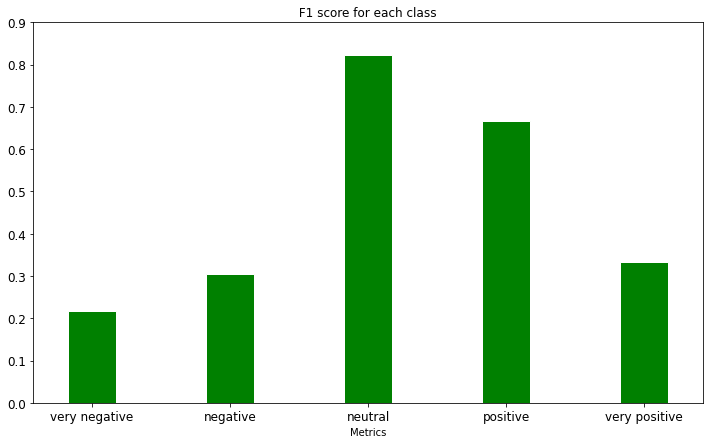

In [73]:
#Analysing by our metric the best classifier on test set is Logistic Regression with One Hot Encoding

cr_dict = classification_report(lr.predict(test_features), test_labels, zero_division = 0, output_dict=True)

#Displaying Bar Graph

index=np.arange(5)
df = pd.DataFrame({'Metrics':['very negative', 'negative', 'neutral','positive','very positive'], 
                   'Values':[cr_dict['0']['f1-score'], cr_dict['1']['f1-score'], cr_dict['2']['f1-score'], cr_dict['3']['f1-score'],cr_dict['4']['f1-score']]})
ax = df.plot.bar(x='Metrics', y='Values', rot=0 ,width=0.35,edgecolor='white',color='green',legend=False)
plt.gcf().set_size_inches(12,7)
plt.tick_params(axis='x',labelrotation=0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yticks(np.arange(0, 1, step=0.1))
# plt.grid()
plt.title(" F1 score for each class ",fontsize=12)
plt.show()

Improve LR(TFIDF)

In [75]:
train_validation = pd.concat([train_data,validation_data],axis=0) #New Dataset for analysis on Trainning and Validation Dataset

In [298]:
prediction_pipeline = Pipeline([
              ('tfidf', TfidfVectorizer()),
              ('logreg', LogisticRegression(max_iter=9000))
              ])
    
prediction_pipeline.fit(train_validation['body'], train_validation['Class'])

print(evaluation_summary(" Initial LRIDF ",prediction_pipeline.predict(test_data['body']), test_labels))

Evaluation for:  Initial LRIDF 
Acc = 0.746 P = 0.598 R = 0.338 F1= 0.367
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.65      0.10      0.17       282
           2       0.74      0.94      0.83      2514
           3       0.76      0.53      0.63      1102
           4       0.83      0.12      0.20        86

    accuracy                           0.75      4016
   macro avg       0.60      0.34      0.37      4016
weighted avg       0.74      0.75      0.71      4016

(0.5978806196543067, 0.7378196792540073, 0.3380673851220449, 0.7460159362549801, 0.7460159362549801, 0.3667336154590227, 0.7087392237898739)


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [130]:
params = {
   'logreg__C': (0.001,0.01,0.1,1,10,100,1000,10000,100000)
}

grid_search = GridSearchCV(prediction_pipeline, param_grid=params, n_jobs= -1 ,verbose= 1, scoring='f1_weighted', cv=2) 

print("parameters:")
print(params,'\n')

grid_search.fit(train_validation['body'], train_validation['Class'])

print("Best score: %0.3f" % grid_search.best_score_)
print("Best parameters set: ")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(params.keys()):
  print("\t%s: %r" % (param_name, best_parameters[param_name]))

parameters:
{'logreg__C': (0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000)} 

Fitting 2 folds for each of 9 candidates, totalling 18 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:  1.5min finished


Best score: 0.725
Best parameters set: 
	logreg__C: 10


In [131]:
prediction_pipeline = Pipeline([
              ('tfidf', TfidfVectorizer()),
              ('logreg', LogisticRegression(max_iter=9000,C=10))
              ])

params = {
   'tfidf__sublinear_tf': (True, False)
}

grid_search = GridSearchCV(prediction_pipeline, param_grid=params, n_jobs= -1 ,verbose= 1, scoring='f1_weighted', cv=2) 

print("parameters:")
print(params,'\n')

grid_search.fit(train_validation['body'], train_validation['Class'])

print("Best score: %0.3f" % grid_search.best_score_)
print("Best parameters set: ")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(params.keys()):
  print("\t%s: %r" % (param_name, best_parameters[param_name]))

parameters:
{'tfidf__sublinear_tf': (True, False)} 

Fitting 2 folds for each of 2 candidates, totalling 4 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:   18.8s finished


Best score: 0.717
Best parameters set: 
	tfidf__sublinear_tf: True


In [132]:
prediction_pipeline = Pipeline([
              ('tfidf', TfidfVectorizer(sublinear_tf= True)),
              ('logreg', LogisticRegression(max_iter=9000,C=10))
              ])
params = {
   'tfidf__max_features': (range(0,50000,5000))
}

grid_search = GridSearchCV(prediction_pipeline, param_grid=params, n_jobs= -1 ,verbose= 1, scoring='f1_weighted', cv=2) #balance scoring as data imbalance

print("parameters:")
print(params,'\n')

grid_search.fit(train_validation['body'], train_validation['Class'])

print("Best score: %0.3f" % grid_search.best_score_)
print("Best parameters set: ")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(params.keys()):
  print("\t%s: %r" % (param_name, best_parameters[param_name]))

parameters:
{'tfidf__max_features': range(0, 50000, 5000)} 

Fitting 2 folds for each of 10 candidates, totalling 20 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  1.2min finished


Best score: 0.725
Best parameters set: 
	tfidf__max_features: 5000


In [133]:
prediction_pipeline = Pipeline([
              ('tfidf', TfidfVectorizer(sublinear_tf= True,max_features = 5000)),
              ('logreg', LogisticRegression(max_iter=9000,C=10))
              ])
params = {
   'logreg__solver' : ('newton-cg', 'lbfgs','sag','saga')
}

grid_search = GridSearchCV(prediction_pipeline, param_grid=params, n_jobs= -1 ,verbose= 1, scoring='f1_weighted', cv=2) #balance scoring as data imbalance

print("parameters:")
print(params,'\n')

grid_search.fit(train_validation['body'], train_validation['Class'])

print("Best score: %0.3f" % grid_search.best_score_)
print("Best parameters set: ")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(params.keys()):
  print("\t%s: %r" % (param_name, best_parameters[param_name]))

# a,b,c,d,e,f,g = evaluation_summary(" LRIDF(Parameters Tuned) Validation ",prediction_pipeline.predict(test_data['body']), test_labels) #weighted f1 on test =0.74

parameters:
{'logreg__solver': ('newton-cg', 'lbfgs', 'sag', 'saga')} 

Fitting 2 folds for each of 4 candidates, totalling 8 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   12.0s finished


Best score: 0.725
Best parameters set: 
	logreg__solver: 'saga'


In [134]:
prediction_pipeline = Pipeline([
              ('tfidf', TfidfVectorizer(sublinear_tf= True,max_features = 5000)),
              ('logreg', LogisticRegression(max_iter=9000,C=10,solver='saga'))
              ])

prediction_pipeline.fit(train_validation['body'], train_validation['Class'])

precison_m_op,precison_w_op,recall_m_op,recall_w_op,accuracy_op,f1_m_op,f1_w_op = evaluation_summary(" LRIDF(Parameters Tuned) Validation Test ",
                                                                                                     prediction_pipeline.predict(test_data['body']), test_labels) #weighted f1 on test = 0.76
print("Confusion Matrix : \n ",confusion_matrix(test_labels,prediction_pipeline.predict(test_data['body'])))

Evaluation for:  LRIDF(Parameters Tuned) Validation Test 
Acc = 0.768 P = 0.664 R = 0.469 F1= 0.523
              precision    recall  f1-score   support

           0       0.67      0.19      0.29        32
           1       0.57      0.32      0.41       282
           2       0.80      0.89      0.84      2514
           3       0.73      0.66      0.69      1102
           4       0.56      0.29      0.38        86

    accuracy                           0.77      4016
   macro avg       0.66      0.47      0.52      4016
weighted avg       0.76      0.77      0.76      4016

Confusion Matrix : 
  [[   6    9   17    0    0]
 [   3   89  183    6    1]
 [   0   56 2233  220    5]
 [   0    1  356  731   14]
 [   0    0   16   45   25]]


Results

In [135]:
results = pd.DataFrame([precison_m_op,precison_w_op,recall_m_op,recall_w_op,accuracy_op,f1_m_op,f1_w_op],
                       index=['Macro precision','Weighted Precision','Macro Recall','Weighted Recall', 'Accuracy','Macro F1','Weighted F1'],columns=['Test Data Statistics'])
display(results)

,Test Data Statistics
Macro precision,0.664407
Weighted Precision,0.756058
Macro Recall,0.469073
Weighted Recall,0.767928
Accuracy,0.767928
Macro F1,0.523237
Weighted F1,0.755387


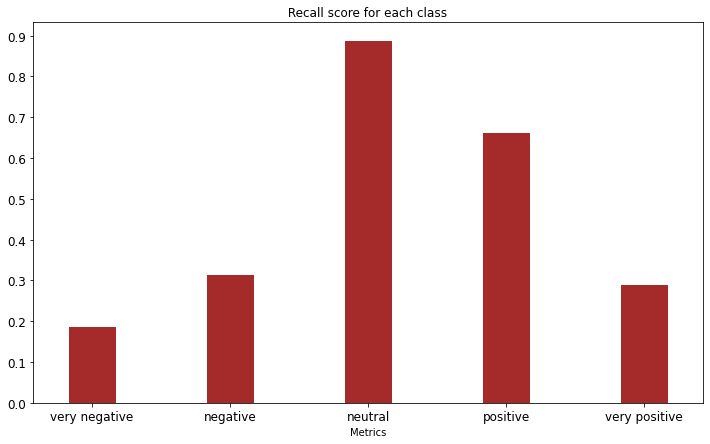

In [136]:
cr_dict = classification_report(test_data['Class'],prediction_pipeline.predict(test_data['body']), zero_division = 0, output_dict=True)
#Displaying Bar Graph

index=np.arange(5)
df = pd.DataFrame({'Metrics':['very negative', 'negative', 'neutral','positive','very positive'], 
                   'Values':[cr_dict['0']['recall'], cr_dict['1']['recall'], cr_dict['2']['recall'], cr_dict['3']['recall'],cr_dict['4']['recall']]})
ax = df.plot.bar(x='Metrics', y='Values', rot=0 ,width=0.35,edgecolor='white',color='brown',legend=False)
plt.gcf().set_size_inches(12,7)
plt.tick_params(axis='x',labelrotation=0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yticks(np.arange(0, 1, step=0.1))
# plt.grid()
plt.title(" Recall score for each class ",fontsize=12)
plt.show()

Adding Features

Adding Features of different Type

In [137]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[ 
    ('imputer', SimpleImputer(strategy='median')),  #For numerical features scaling
    ('scaler', StandardScaler())])


text_transformer = TfidfVectorizer(sublinear_tf= True,max_features=5000)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, ['sentiment.subjectivity']),
        ('tfidf_1', text_transformer, 'body'),
        ('tfidf_2', text_transformer, 'majority_type'),
        ],
                    remainder='drop')


## Run evaluation with classifier
def evaluateClassifier(classif):
  clf = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', classif)])

  clf.fit(train_validation,train_validation['sentiment.polarity'])

  y_pred = clf.predict(test_data)
  
  return y_pred
  # print(metrics.classification_report(y_test, y_pred, zero_division=0))

y_pred = evaluateClassifier(LogisticRegression(max_iter=9000,C=10,solver='saga'))

In [138]:
precison_m_3,precison_w_3,recall_m_3,recall_w_3,accuracy_3,f1_m_3,f1_w_3=evaluation_summary("LR", y_pred,test_data['sentiment.polarity'])

Evaluation for: LR
Acc = 0.805 P = 0.676 R = 0.570 F1= 0.611
               precision    recall  f1-score   support

     negative       0.61      0.44      0.51       282
      neutral       0.85      0.89      0.87      2514
     positive       0.74      0.75      0.74      1102
very negative       0.70      0.44      0.54        32
very positive       0.47      0.34      0.39        86

     accuracy                           0.80      4016
    macro avg       0.68      0.57      0.61      4016
 weighted avg       0.80      0.80      0.80      4016



In [139]:
results = pd.DataFrame([precison_m_3,precison_w_3,recall_m_3,recall_w_3,accuracy_3,f1_m_3,f1_w_3],
                       index=['Macro precision','Weighted Precision','Macro Recall','Weighted Recall', 'Accuracy','Macro F1','Weighted F1'],columns=['Test Data Statistics After Feature Addition'])
display(results)

,Test Data Statistics After Feature Addition
Macro precision,0.675685
Weighted Precision,0.797067
Macro Recall,0.569800
Weighted Recall,0.804532
Accuracy,0.804532
Macro F1,0.611443
Weighted F1,0.799006


Text(0.5, 1.0, ' Recall score for each class ')

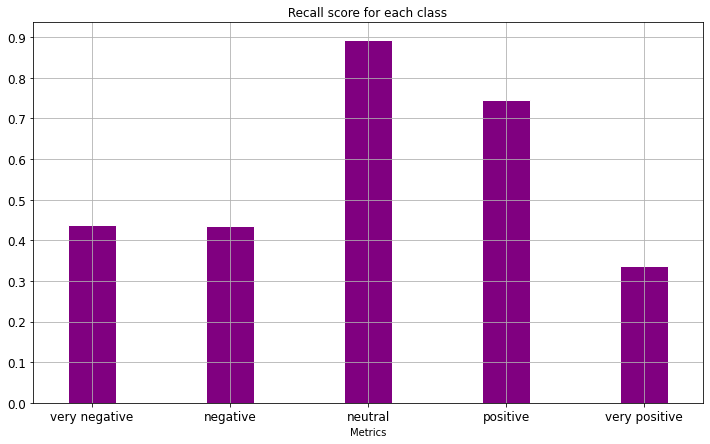

In [140]:
cr_dict = classification_report(test_data['sentiment.polarity'],y_pred, zero_division = 0, output_dict=True)
#Displaying Bar Graph

index=np.arange(5)
df = pd.DataFrame({'Metrics':['very negative', 'negative', 'neutral','positive','very positive'], 
                   'Values':[cr_dict['very negative']['recall'], cr_dict['negative']['recall'], cr_dict['neutral']['recall'], cr_dict['positive']['recall'],cr_dict['very positive']['recall']]})
ax = df.plot.bar(x='Metrics', y='Values', rot=0 ,width=0.35,edgecolor='white',color='purple',legend=False)
plt.gcf().set_size_inches(12,7)
plt.tick_params(axis='x',labelrotation=0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yticks(np.arange(0, 1, step=0.1))
plt.grid()
plt.title(" Recall score for each class ",fontsize=12)